# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [3]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [7]:
from platform import python_version

print(python_version())


3.10.12


In [30]:
print(np.__version__)

1.26.3


# Define all functions

In [7]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [8]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [9]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [10]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [11]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [8]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [13]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [15]:
#Load file
tt_md = pd.read_pickle("pickle_files/training_data_md.pkl")
tt_md.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,s1019,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [16]:
#Extract only SNPs for feature selection

In [17]:
feature= tt_md.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1019_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [18]:
target = tt_md["MD"]
target.head()

new_line
s100_BeiJing_2013    155.0
s100_HeNan_2015      115.0
s1014_HeNan_2014     108.0
s1014_HeNan_2015     104.0
s1019_HeNan_2015     113.0
Name: MD, dtype: float64

In [19]:
cov = tt_md.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [38]:
# If you want to run bayessearch CV for the full training, split the dataset and run like so 
from sklearn.pipeline import make_pipeline
def run_bayes_lasso_on_feature_subsets(X, y, n_splits=8):
    # Split features horizontally into subsets
    feature_subsets = np.array_split(X, n_splits, axis=1)
    best_models = []
    
    for i, X_subset in enumerate(feature_subsets):
        print(f"\Feature Subset {i+1}/{n_splits}: Shape = {X_subset.shape}")

        # Define pipeline: StandardScaler + Lasso
        lasso_pipeline = make_pipeline(
            Lasso(max_iter=100000)
        )

        # Define hyperparameter search space
        param_search = {
            'lasso__alpha': Real(1e-5, 1.0, prior='log-uniform')
        }

        # Create BayesSearchCV
        bayes_cv = BayesSearchCV(
            lasso_pipeline,
            search_spaces=param_search,
            n_iter=10,
            cv=3,
            scoring=None,
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        # Fit
        bayes_cv.fit(X_subset, y)
        print(f"Best alpha: {bayes_cv.best_params_['lasso__alpha']:.5f}")
        
        # Save the best model
        best_models.append(bayes_cv.best_estimator_)

    return best_models

#best_lasso = run_bayes_lasso_on_feature_subsets(X_train, y_train, n_splits=8)

In [20]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s597_HeNan_2015,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s2866_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,1,1,1
s832_HeNan_2014,0,0,1,0,0,1,1,0,2,1,...,0,0,0,0,0,1,0,0,1,1
s601_HeNan_2015,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1250_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [21]:
best_lasso = bayesian_lasso_search(X_train_subset, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.489e+04, tolerance: 5.502e+01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+02, tolerance: 5.480e+01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Du

Best Lasso hyperparameters: OrderedDict([('alpha', 0.5989491205267933)])


In [20]:
# Create a Lasso Regression model with the best parameters from bayes CV
#alpha = 0.5989  # Regularization strength (adjust from best_params)
alpha = 0.7352
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.7352)

In [21]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [22]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [23]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [24]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [25]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [26]:
new_data = tt_md[selected_feature]
print(new_data.head())

                   Chr1_16121722  Chr1_50820261  Chr1_53630801  Chr1_56403929  \
new_line                                                                        
s100_BeiJing_2013              2              1              0              2   
s100_HeNan_2015                2              1              0              2   
s1014_HeNan_2014               0              2              0              2   
s1014_HeNan_2015               0              2              0              2   
s1019_HeNan_2015               0              0              0              0   

                   Chr1_56955989  Chr2_5508248  Chr2_15038072  Chr2_19085404  \
new_line                                                                       
s100_BeiJing_2013              0             1              2              0   
s100_HeNan_2015                0             1              2              0   
s1014_HeNan_2014               0             2              0              0   
s1014_HeNan_2015               0

In [27]:
new_data.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr18_58493757,Chr18_59024775,Chr19_37961441,Chr19_42550797,Chr19_45117707,Chr20_2472341,Chr20_16916284,Chr20_40195415,Chr20_43468889,Chr20_50084112
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s100_HeNan_2015,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s1014_HeNan_2014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1014_HeNan_2015,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1019_HeNan_2015,0,0,0,0,0,2,2,0,0,0,...,0,2,0,0,0,0,0,0,2,2


In [28]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 120 entries, Chr1_16121722 to Chr20_50084112
dtypes: int64(120)
memory usage: 2.3+ MB


In [29]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,2,1,0,2,0,1,2,0,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,2,1,0,2,0,1,2,0,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,0,2,0,2,0,2,0,0,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,0,2,0,2,0,2,0,0,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,0,0,0,0,0,2,2,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [30]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 132 entries, Chr1_16121722 to MD
dtypes: float64(5), int64(127)
memory usage: 2.5+ MB


In [31]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,2,1,0,2,0,1,2,0,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,2,0,2,0,2,0,0,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,2,0,2,0,2,0,0,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,2,2,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [32]:
fs_data.to_pickle("fs_md_lasso_training_data_new.pkl")

In [9]:
fs_data = pd.read_pickle("../pickle_files/fs_md_lasso_training_data_new.pkl")

In [33]:
fs_data.to_csv("fs_md_lasso_training_data_new.txt")

## All traits

In [10]:
X_all = fs_data.drop("MD", axis=1).values
y_all = fs_data["MD"].values

In [11]:
X_dupe = fs_data.drop("MD", axis=1)
X_dupe.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [18]:
X_train.shape

(2205, 131)

In [19]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.3820092511985299), ('colsample_bytree', 0.8245471147639104), ('gamma', 5.531214047064075e-07), ('learning_rate', 0.07843192878600559), ('max_delta_step', 14), ('max_depth', 31), ('min_child_weight', 10), ('n_estimators', 93), ('reg_alpha', 1e-09), ('reg_lambda', 18.63313171382667), ('subsample', 1.0)])


In [20]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6611641941294764
RMSE for dataset is:9.497783443871636& mean of this fold is 116.90612244897959
this is 8.124282325775264% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7057373613568624
RMSE for dataset is:8.471378212776791& mean of this fold is 115.38367346938776
this is 7.341921051789288% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6654647261427741
RMSE for dataset is:9.060508838458581& mean of this fold is 116.9469387755102
this is 7.747538271053861% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6895035739911695
RMSE for dataset is:8.205493143295477& mean of this fold is 114.55102040816327
this is 7.163177695020104% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6902378032243446
RMSE for datase

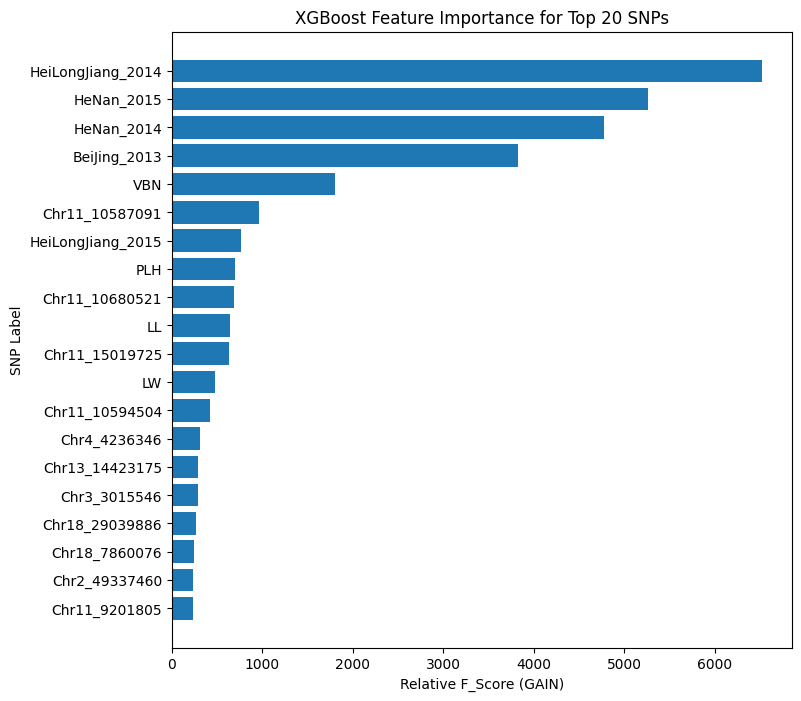

In [32]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [33]:
explainer = shap.Explainer(best_xgbr_model)

In [34]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

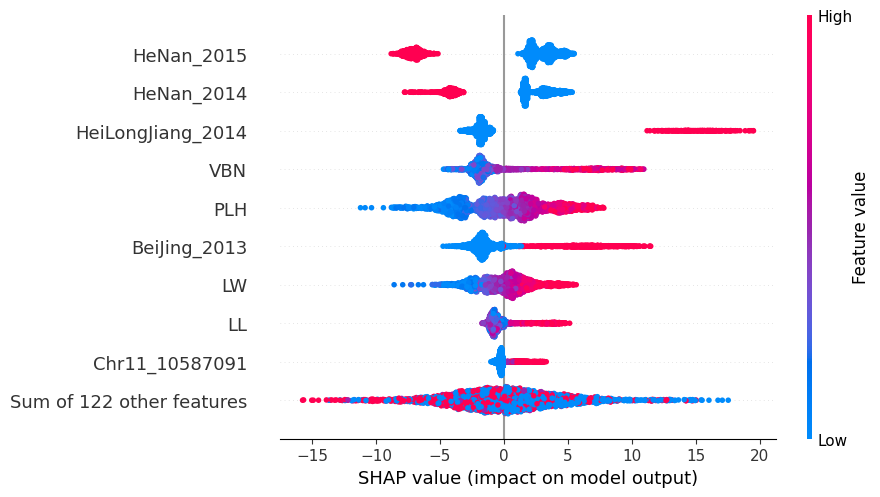

In [35]:
shap.plots.beeswarm(shap_values, show=False)

In [13]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [14]:
holdout_data = holdout_data.set_index('Line')

In [15]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [16]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [17]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [18]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [19]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 131 entries, Chr1_16121722 to landrace
dtypes: float64(4), int64(127)
memory usage: 632.2+ KB


In [20]:
y_holdout.shape

(613, 1)

In [21]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [22]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

NameError: name 'best_xgbr_model' is not defined

In [31]:
pickle.dump(best_xgbr_model, open("lasso_allfeats_xgbr_md.pickle.dat", "wb"))

In [24]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_xgbr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.75
RMSE of Holdout: 9.63
Mean of Holdout: 117.42
This is 8.20% of the mean pheno data
0 117.0 114.51184
1 148.0 145.0579
2 117.0 111.10986
3 121.0 118.76292
4 119.0 123.82819


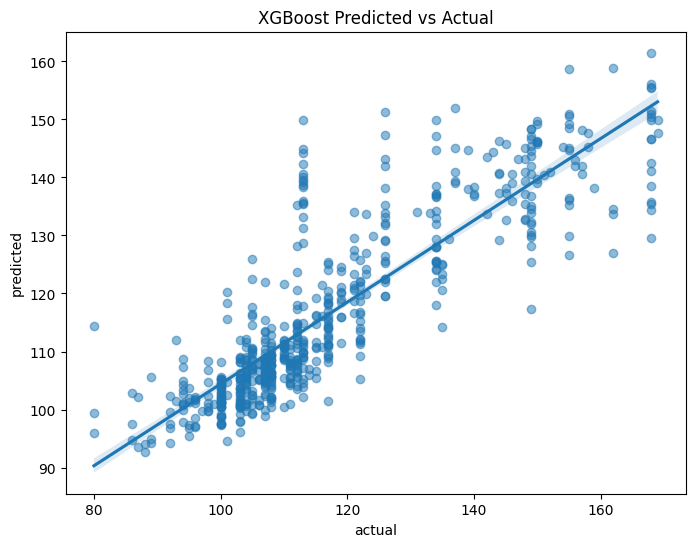

In [25]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [61]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 25), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [62]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.25700081732293
RMSE for dataset is:10.473867056164313& mean of this fold is 115.84489795918367
this is 9.041284718343515% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.24412637008817473
RMSE for dataset is:10.937292825263485& mean of this fold is 115.2204081632653
this is 9.492496164191271% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.39369044273903175
RMSE for dataset is:9.655307335918343& mean of this fold is 116.89387755102041
this is 8.259891397395139% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.23226295799520313
RMSE for dataset is:10.906794551065618& mean of this fold is 117.35102040816327
this is 9.294162516124922% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.29014715474994246
RMSE for d

In [64]:
pickle.dump(best_rfr_model, open("lasso_allfeats_rfr_md.pickle.dat", "wb"))

In [26]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.67
RMSE of Holdout: 11.07
Mean of Holdout: 117.42
This is 9.43% of the mean pheno data
0 117.0 114.568
1 148.0 140.438
2 117.0 113.946
3 121.0 127.3
4 119.0 123.916


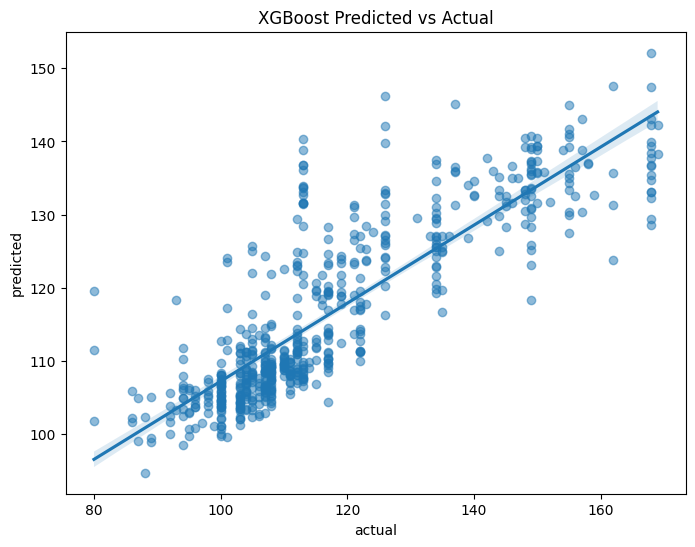

In [27]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [65]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [66]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.673643142463926
RMSE for dataset is:9.41591803237392& mean of this fold is 115.43673469387755
this is 8.156777872610178% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6820701698841402
RMSE for dataset is:9.073245315197966& mean of this fold is 115.5734693877551
this is 7.850629874886553% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6036684975214026
RMSE for dataset is:10.078007398681116& mean of this fold is 115.58775510204082
this is 8.718923029333215% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5433978450961552
RMSE for dataset is:10.70980978173515& mean of this fold is 117.4530612244898
this is 9.118374327651903% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.582671215724271
RMSE for dataset i

In [68]:
pickle.dump(best_svr_model, open("lasso_allfeats_svr_md.pickle.dat", "wb"))

In [28]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.68
RMSE of Holdout: 10.89
Mean of Holdout: 117.42
This is 9.28% of the mean pheno data
0 117.0 118.73006134195887
1 148.0 141.57464190894055
2 117.0 112.34910373455708
3 121.0 128.01590646668913
4 119.0 119.49053099661663


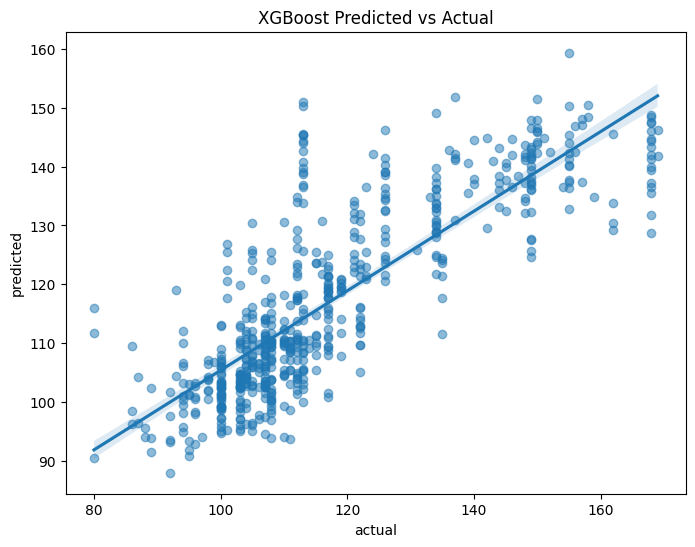

In [29]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only Location

In [30]:
snps_loc= fs_data.drop(['MD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,0,1,0,0,0,1


In [31]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 127 entries, Chr1_16121722 to landrace
dtypes: int64(127)
memory usage: 2.4+ MB


In [32]:
snps_loc_dupe= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,0,1,0,0,0,1


In [33]:
y_all = fs_data["MD"].values

In [34]:
# Split training set into training and validation

In [74]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [75]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [76]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 1.0), ('gamma', 0.007139636836005863), ('learning_rate', 1.0), ('max_delta_step', 20), ('max_depth', 50), ('min_child_weight', 3), ('n_estimators', 166), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])


In [77]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7084652262923734
RMSE for dataset is:8.93885580402618& mean of this fold is 117.43673469387755
this is 7.6116351730377225% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6567895245228602
RMSE for dataset is:8.645050242225995& mean of this fold is 113.82857142857142
this is 7.59479815456601% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6788422622276503
RMSE for dataset is:9.529016021686042& mean of this fold is 116.6734693877551
this is 8.167251793993634% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7124850857467872
RMSE for dataset is:8.032979582589688& mean of this fold is 114.11836734693877
this is 7.039164482758588% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6676903741682843
RMSE for dataset

In [35]:
#pickle.dump(best_xgbr_model, open("lasso_onlyloc_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_onlyloc_xgbr_md.pickle.dat", "rb"))

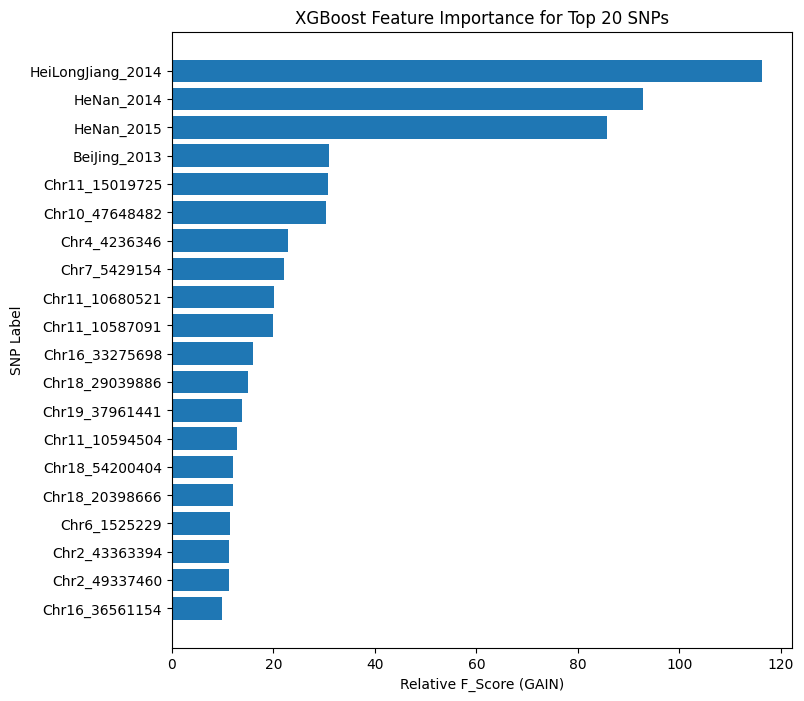

In [79]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

In [80]:
explainer = shap.Explainer(best_xgbr_model)

In [81]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

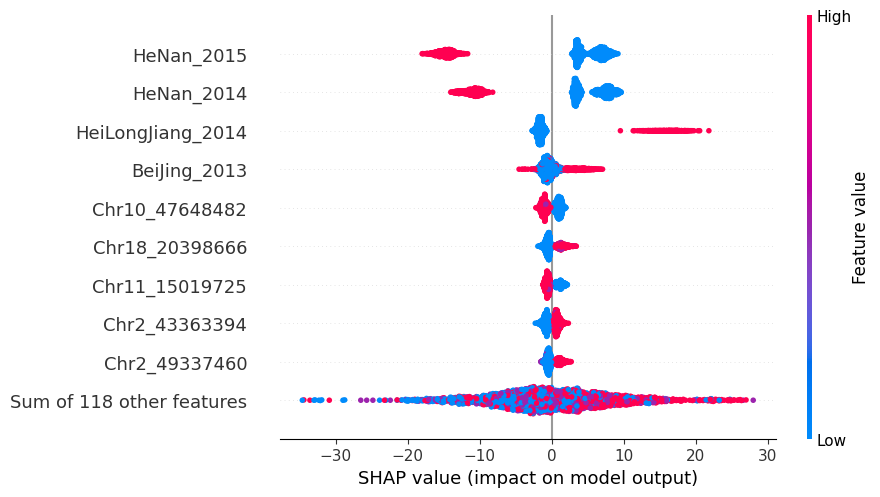

In [82]:
shap.plots.beeswarm(shap_values, show=False)

In [83]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [84]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [36]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [37]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [38]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [39]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 127 entries, Chr1_16121722 to landrace
dtypes: int64(127)
memory usage: 613.0+ KB


In [40]:
X_holdout.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,1,0,0,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,1,0,0,0,0,1
s101,2,2,0,0,2,2,0,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s101,2,2,0,0,2,2,0,0,2,0,...,0,0,0,0,0,0,0,1,0,1


In [41]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.74
RMSE of Holdout: 9.78
Mean of Holdout: 117.42
This is 8.33% of the mean pheno data
0 117.0 117.7964
1 148.0 146.60162
2 117.0 113.28179
3 121.0 123.517075
4 119.0 122.716156


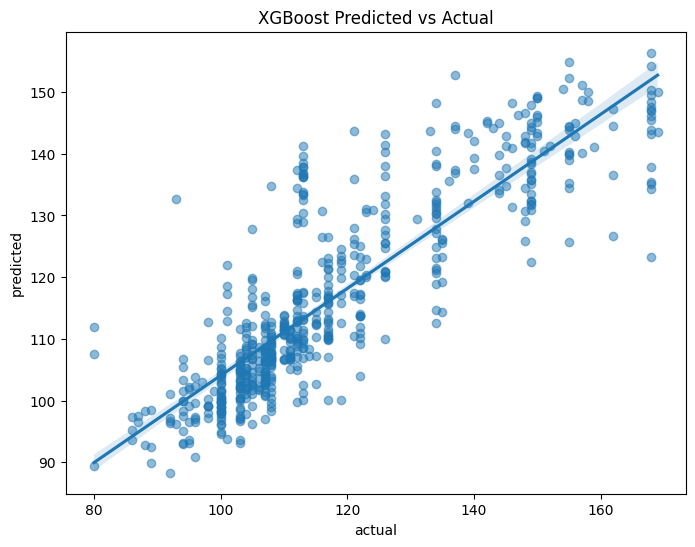

In [42]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [92]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 117.0 117.7964
1 148.0 146.60162
2 117.0 113.28179
3 121.0 123.517075
4 119.0 122.716156
5 94.0 99.969185


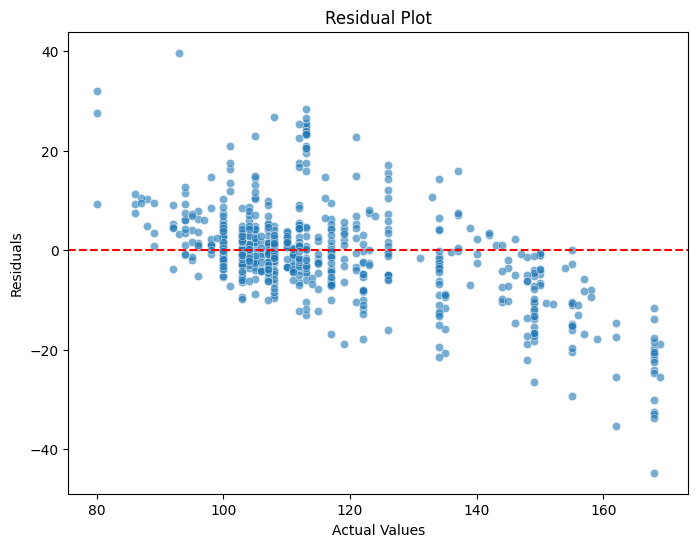

In [93]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [94]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [True, 13, 'sqrt', 1.0, 1, 2, 500] before, using random point [True, 41, 'sqrt', 0.5548164066476641, 8, 4, 442]
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 26), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [95]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.24545398362739235
RMSE for dataset is:11.690533696784174& mean of this fold is 115.83061224489796
this is 10.092784170101037% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.06466753604370834
RMSE for dataset is:10.838760799298004& mean of this fold is 116.18367346938776
this is 9.328987865195893% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.2525261478988525
RMSE for dataset is:12.10779943240051& mean of this fold is 115.36734693877551
this is 10.49499685454847% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.15736957718270084
RMSE for dataset is:11.296690768226117& mean of this fold is 115.35102040816327
this is 9.793316719915781% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.13631460269185092
R

In [96]:
pickle.dump(best_rfr_model, open("lasso_onlyloc_rfr_md.pickle.dat", "wb"))

In [43]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/lasso_onlyloc_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.59
RMSE of Holdout: 12.41
Mean of Holdout: 117.42
This is 10.57% of the mean pheno data
0 117.0 116.516
1 148.0 130.834
2 117.0 110.922
3 121.0 126.288
4 119.0 118.504


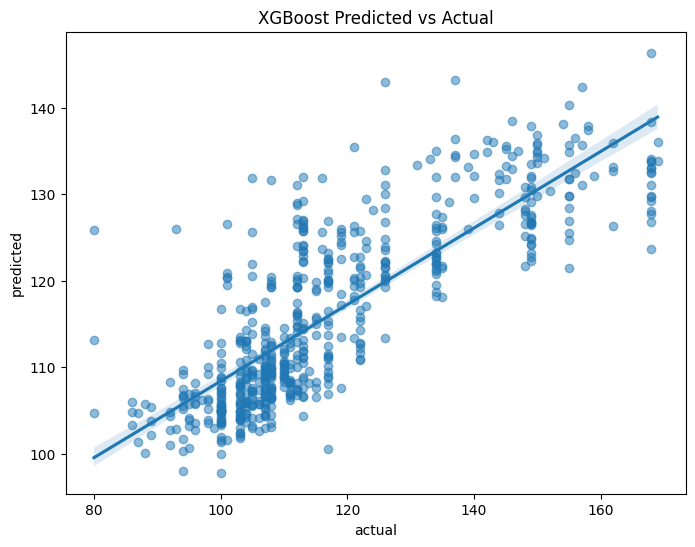

In [44]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [98]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [99]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5131832543475732
RMSE for dataset is:10.906569697976453& mean of this fold is 115.19591836734693
this is 9.467843872034267% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4218438925392488
RMSE for dataset is:11.264808145801219& mean of this fold is 116.41224489795918
this is 9.6766522762922% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4687137657550272
RMSE for dataset is:11.141753875984& mean of this fold is 116.71224489795918
this is 9.546345274846841% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5781422495674948
RMSE for dataset is:10.235860628218619& mean of this fold is 116.84081632653061
this is 8.760517899509402% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4908294253484601
RMSE for datase

In [103]:
pickle.dump(best_svr_model, open("lasso_onlyloc_svr_md.pickle.dat", "wb"))

In [45]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.62
RMSE of Holdout: 11.93
Mean of Holdout: 117.42
This is 10.16% of the mean pheno data
0 117.0 112.2734139144604
1 148.0 133.39509049595765
2 117.0 110.35992112991093
3 121.0 135.14074285894432
4 119.0 124.58228951413204


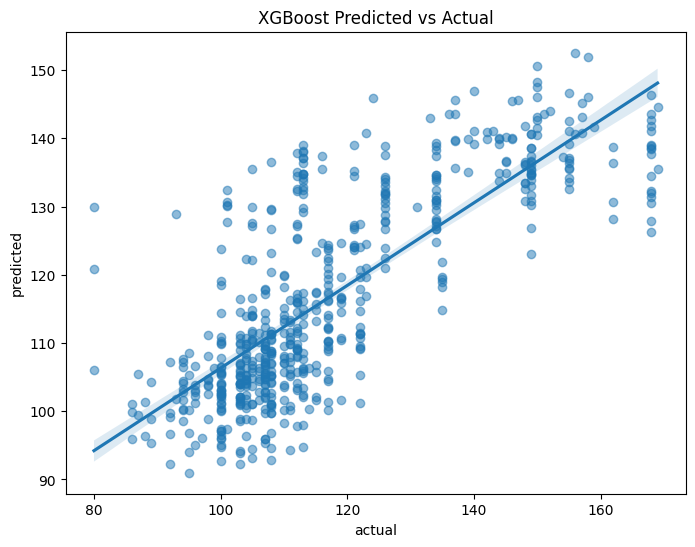

In [46]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [47]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 132 entries, Chr1_16121722 to MD
dtypes: float64(5), int64(127)
memory usage: 2.5+ MB


In [48]:
only_snps = fs_data.iloc[:, 0:120]
only_snps.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr18_58493757,Chr18_59024775,Chr19_37961441,Chr19_42550797,Chr19_45117707,Chr20_2472341,Chr20_16916284,Chr20_40195415,Chr20_43468889,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,0,0,0,0,0,0,2,2


In [49]:
only_snps_dupe = fs_data.iloc[:, 0:120]
only_snps.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr18_58493757,Chr18_59024775,Chr19_37961441,Chr19_42550797,Chr19_45117707,Chr20_2472341,Chr20_16916284,Chr20_40195415,Chr20_43468889,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,0,0,0,0,0,0,2,2


In [50]:
y_all = fs_data["MD"]
y_all.head()

Line
s100     155.0
s100     115.0
s1014    108.0
s1014    104.0
s1019    113.0
Name: MD, dtype: float64

### Run models

In [112]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [113]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [114]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5919339973425557), ('colsample_bytree', 0.0212763601028913), ('gamma', 5.79472066371887e-08), ('learning_rate', 0.08614408493107856), ('max_delta_step', 12), ('max_depth', 17), ('min_child_weight', 1), ('n_estimators', 103), ('reg_alpha', 5.0118600481912154e-08), ('reg_lambda', 6.21517501138444e-07), ('subsample', 0.27050366493544487)])


In [115]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -24.324107154756874
RMSE for dataset is:18.49156636046841& mean of this fold is 116.45714285714286
this is 15.878430388037154% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.394391404260467
RMSE for dataset is:17.324289440725245& mean of this fold is 115.76530612244898
this is 14.965009829802328% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -21.364955364713218
RMSE for dataset is:18.225220775910483& mean of this fold is 116.99591836734695
this is 15.577655212454886% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.725966709321387
RMSE for dataset is:18.909748772086363& mean of this fold is 116.05714285714286
this is 16.29348121671646% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.68324652439694
RMSE

In [116]:
pickle.dump(best_xgbr_model, open("lasso_onlysnps_xgbr_md.pickle.dat", "wb"))

In [51]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_xgbr_md.pickle.dat", "rb"))

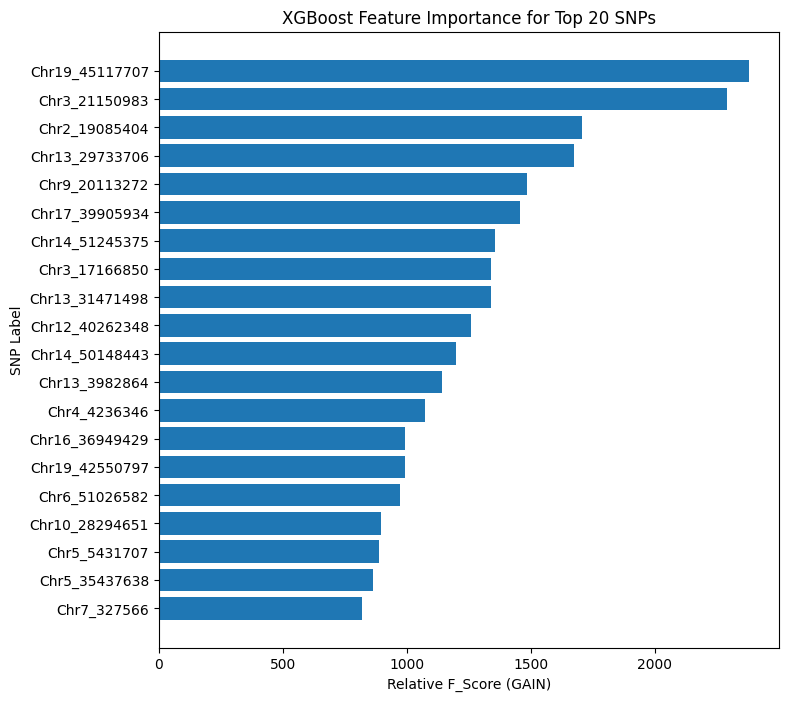

In [117]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [118]:
explainer = shap.Explainer(best_xgbr_model)

In [119]:
shap_values = explainer(only_snps_dupe)

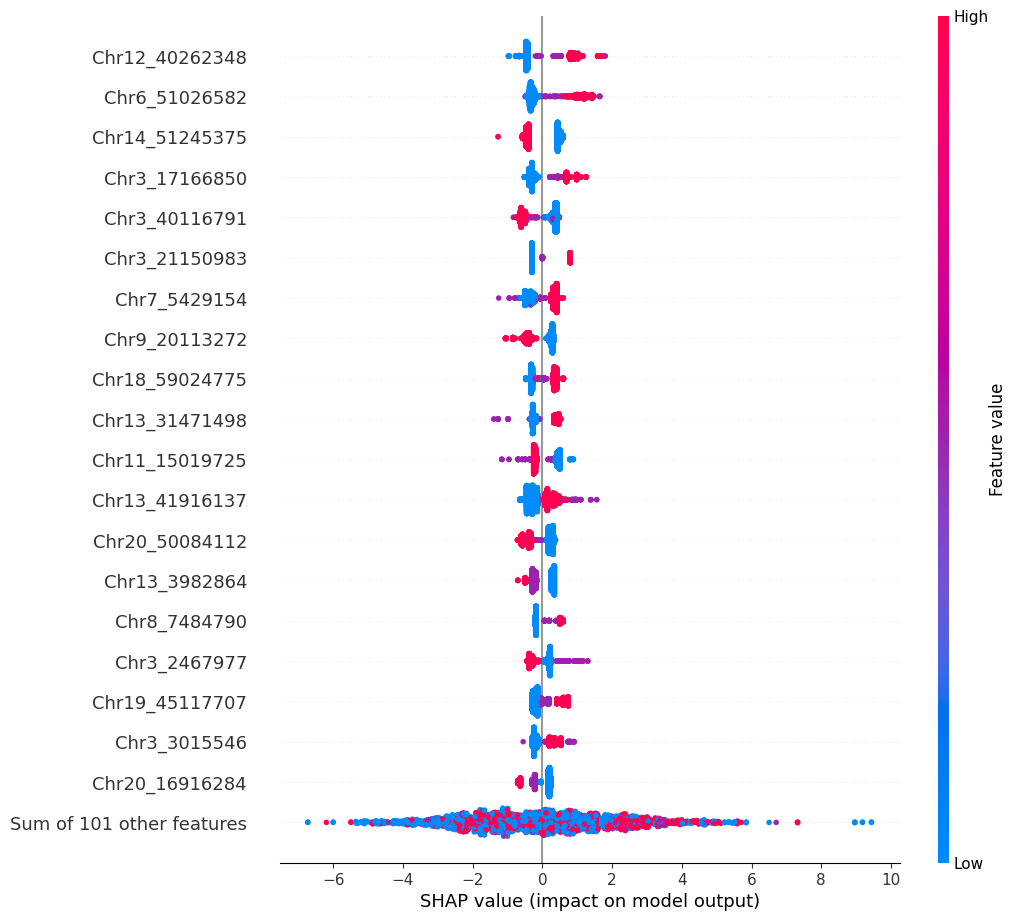

In [120]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [121]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [122]:
holdout_data = holdout_data.set_index('Line')

In [52]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [53]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [54]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [55]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 120 entries, Chr1_16121722 to Chr20_50084112
dtypes: int64(120)
memory usage: 579.5+ KB


In [56]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.04
RMSE of Holdout: 18.97
Mean of Holdout: 117.42
This is 16.15% of the mean pheno data
0 117.0 118.88642
1 148.0 112.595764
2 117.0 111.175865
3 121.0 120.50565
4 119.0 120.50565


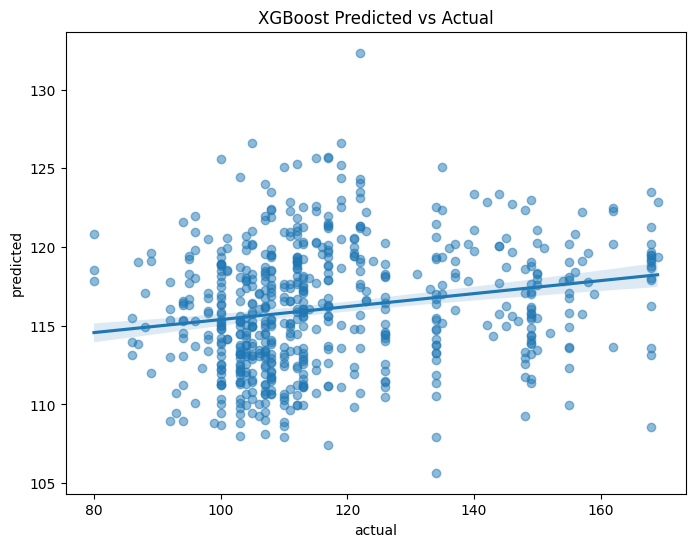

In [57]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [129]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 8), ('min_samples_split', 20), ('n_estimators', 500)])


In [130]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.080866777192938
RMSE for dataset is:19.806842281012507& mean of this fold is 118.4938775510204
this is 16.71549846318785% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.95553202130087
RMSE for dataset is:16.486550880508716& mean of this fold is 113.56326530612245
this is 14.51750338110425% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -16.47650373969283
RMSE for dataset is:17.879538070479843& mean of this fold is 116.76530612244898
this is 15.312372025753952% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.893020878075356
RMSE for dataset is:17.12549918195457& mean of this fold is 115.28571428571429
this is 14.85483200417373% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.36407032192558
RMSE for 

In [131]:
pickle.dump(best_rfr_model, open("lasso_onlysnps_rfr_md.pickle.dat", "wb"))

In [58]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.03
RMSE of Holdout: 19.02
Mean of Holdout: 117.42
This is 16.20% of the mean pheno data
0 117.0 119.14775299061381
1 148.0 110.96542832219994
2 117.0 112.81016154118295
3 121.0 121.04417542969034
4 119.0 121.04417542969034


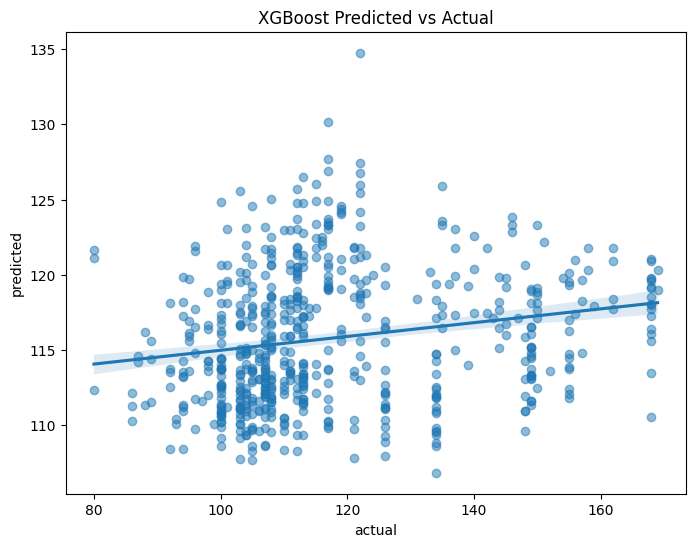

In [59]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [133]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [134]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.737482750544157
RMSE for dataset is:17.639646256313096& mean of this fold is 115.98775510204082
this is 15.20819696940813% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.822272146687301
RMSE for dataset is:15.83957665220803& mean of this fold is 112.7673469387755
this is 14.046243954650961% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.3390175661334975
RMSE for dataset is:17.334653398869598& mean of this fold is 116.61224489795919
this is 14.865208549958178% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.977644243154749
RMSE for dataset is:17.225864220737947& mean of this fold is 115.79591836734694
this is 14.876054755307708% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.6705010832627485
RMSE fo

In [135]:
pickle.dump(best_svr_model, open("lasso_onlysnps_svr_md.pickle.dat", "wb"))

In [60]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.10
RMSE of Holdout: 20.27
Mean of Holdout: 117.42
This is 17.27% of the mean pheno data
0 117.0 115.73915828054758
1 148.0 105.60497146341508
2 117.0 108.26396891590092
3 121.0 127.63842187781857
4 119.0 127.63842187781857


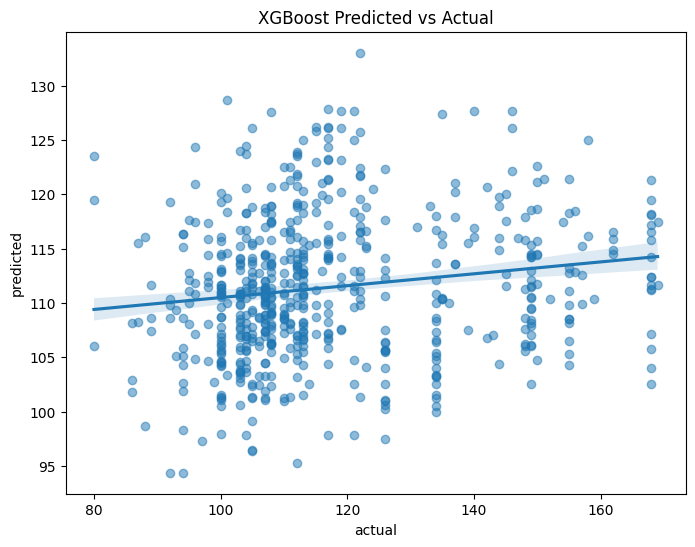

In [61]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)